In [7]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re


ufos_dirty = pd.read_csv('scrubbed.csv')

/var/folders/wg/xkc73kbs5t153f1jrffmc_7w0000gn/T/ipykernel_1667/1648049598.py:7: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  ufos_dirty = pd.read_csv('scrubbed.csv')


In [2]:
# Drop columns
ufo_data = ufos_dirty.drop(columns=['duration (hours/min)', 'date posted'])

# Convert datetime
ufo_data['datetime'] = pd.to_datetime(ufo_data['datetime'], errors='coerce')
ufo_data = ufo_data[ufo_data['country'] == 'us']
# Convert duration to numeric
ufo_data['duration (seconds)'] = pd.to_numeric(
    ufo_data['duration (seconds)'],
    errors='coerce'
)

# Drop rows with missing datetime or duration
ufo_data = ufo_data.dropna(subset=['datetime', 'duration (seconds)'])

# Filter
ufo_data = ufo_data[
    (ufo_data['datetime'].dt.year >= 2010) &
    (ufo_data['duration (seconds)'] >= 120)
]

ufo_data = ufo_data.rename(columns={'longitude ': 'longitude'})


In [8]:
ufo_data.to_csv('ufo_data.csv', index=False)

In [9]:
ufo_data.columns

Index(['datetime', 'city', 'state', 'country', 'shape', 'duration (seconds)',
       'comments', 'latitude', 'longitude'],
      dtype='object')

In [3]:
ufo_data.head()

,datetime,city,state,country,shape,duration (seconds),comments,latitude,longitude
212,2010-10-10 01:00:00,orchard park,ny,us,light,7200.0,Xmas colored rotating lights. ((NUFORC Note: ...,42.7675000,-78.744167
213,2010-10-10 02:30:00,harrisburg,pa,us,circle,240.0,possible UFO sighting,40.2736111,-76.884722
214,2010-10-10 03:00:00,euclid,oh,us,circle,180.0,2 objects blinking red and white&#44 disappear...,41.5930556,-81.526944
215,2010-10-10 08:30:00,starr,sc,us,formation,600.0,Strange orange lights in the night sky,34.3769444,-82.695833
216,2010-10-10 12:00:00,greenwich,ct,us,light,240.0,&quot;Star&quot; like objects during clear day...,41.0263889,-73.628889


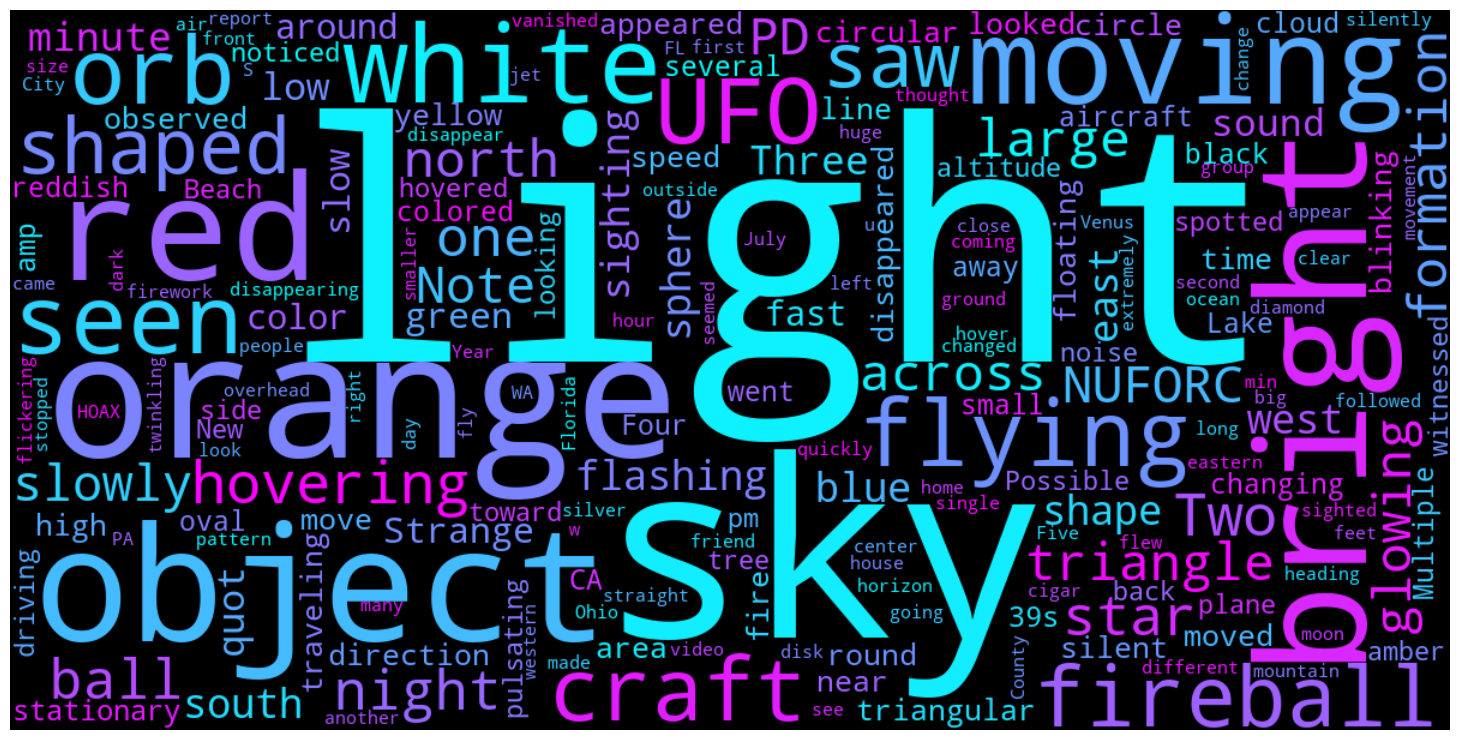

In [6]:
# Clean the comments text
text = " ".join(ufo_data["comments"].dropna().astype(str))

# Optional: remove common stopwords or noise
text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs

# Generate the word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="black",
    colormap="cool",         # try: "plasma", "viridis", "Oranges", etc.
    max_words=200,
    collocations=False,      # avoids duplicate bigrams
    stopwords=None           # uses built-in English stopwords by default
).generate(text)

# Display it
plt.figure(figsize=(15, 7.5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.savefig("ufo_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()